# agentv13_supervisor_multi_agent — Supervisor Multi-Agent Pattern

This version introduces a supervisor that delegates to specialist agents.

Graph:

```text
START → supervisor → selected specialists → supervisor_synthesis → END
```

The supervisor can select one or more agents.


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define state

Multiple agents write to `agent_outputs`.

Therefore `agent_outputs` uses `operator.add` to merge branch outputs.


In [3]:
import operator
from typing import Annotated, Literal, TypedDict

AgentName = Literal["sql_agent", "rag_agent", "ops_agent"]

class AgentState(TypedDict, total=False):
    input: str
    selected_agents: list[AgentName]
    agent_outputs: Annotated[list[str], operator.add]
    final_answer: str


## 4. Fallback deterministic selection


In [4]:
def fallback_select_agents(text: str) -> list[AgentName]:
    normalized = text.lower()
    selected: list[AgentName] = []

    if any(term in normalized for term in ["sql", "metric", "metrics", "database", "volume", "failure", "latency", "count"]):
        selected.append("sql_agent")

    if any(term in normalized for term in ["doc", "docs", "pdf", "runbook", "release notes", "policy", "knowledge"]):
        selected.append("rag_agent")

    if any(term in normalized for term in ["ops", "operation", "restart", "service", "cloud", "aws", "endpoint", "dns", "connectivity"]):
        selected.append("ops_agent")

    if not selected:
        selected = ["sql_agent", "rag_agent", "ops_agent"]

    return selected


## 5. Supervisor node

The supervisor uses an LLM to select specialist agents.


In [5]:
import json
from langchain_openai import ChatOpenAI

def supervisor_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    prompt = f'''
You are a supervisor agent.

Available specialist agents:
- sql_agent: database metrics, failure counts, latency, volume, structured analytics
- rag_agent: PDFs, runbooks, release notes, policies, document lookup
- ops_agent: operational checks, service health, AWS/cloud remediation, connectivity, DNS, endpoints

Select all agents needed to answer the user request.

Return only valid JSON:
{{"selected_agents": ["sql_agent", "rag_agent"]}}

Rules:
- Select multiple agents if the request requires multiple evidence sources.
- Select sql_agent for metrics, counts, failures, latency, volume, database analytics.
- Select rag_agent for docs, runbooks, PDFs, release notes, policy questions.
- Select ops_agent for operational checks, remediation, cloud/service investigation.
- If unclear, select all agents.

User request:
{state["input"]}
'''

    try:
        response = llm.invoke(prompt).content.strip()
        parsed = json.loads(response)
        selected = parsed.get("selected_agents", [])
        allowed = {"sql_agent", "rag_agent", "ops_agent"}
        selected = [agent for agent in selected if agent in allowed]
        if not selected:
            selected = fallback_select_agents(state["input"])
    except Exception:
        selected = fallback_select_agents(state["input"])

    return {
        "selected_agents": selected,
        "agent_outputs": [],
    }


## 6. Dynamic delegation with Send

The supervisor can delegate to one or many specialists.


In [6]:
from langgraph.constants import Send

def delegate_to_selected_agents(state: AgentState):
    return [
        Send(agent_name, {"input": state["input"]})
        for agent_name in state["selected_agents"]
    ]


/tmp/ipykernel_22048/1275975164.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


## 7. Specialist agents

These are specialist-agent placeholders.

v8 contains the full SQL tool loop.

v12 contains the full RAG implementation.

v13 focuses on orchestration.


In [7]:
def sql_agent_node(state: AgentState) -> AgentState:
    return {
        "agent_outputs": [
            "SQL Agent: Metrics indicate CHECK-DOMAIN timeout volume increased after release R13, with CONNECTION_TIMEOUT as the likely dominant failure reason."
        ]
    }

def rag_agent_node(state: AgentState) -> AgentState:
    return {
        "agent_outputs": [
            "RAG Agent: Release/runbook context indicates R13 introduced connection pool changes and CHECK-DOMAIN latency risk under saturation."
        ]
    }

def ops_agent_node(state: AgentState) -> AgentState:
    return {
        "agent_outputs": [
            "Ops Agent: Recommended checks are registry endpoint health, DNS resolver latency, upstream connectivity, and connection pool saturation."
        ]
    }


## 8. Supervisor synthesis node


In [8]:
def supervisor_synthesis_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

    outputs = "\n".join(f"- {item}" for item in state.get("agent_outputs", []))
    selected = ", ".join(state.get("selected_agents", []))

    prompt = f'''
User request:
{state["input"]}

Selected agents:
{selected}

Specialist outputs:
{outputs}

Write a concise final answer that synthesizes specialist outputs.
Include:
1. likely conclusion
2. supporting evidence by specialist
3. recommended next action
Do not mention agents that were not selected.
'''

    response = llm.invoke(prompt)
    return {"final_answer": response.content}


## 9. Build graph


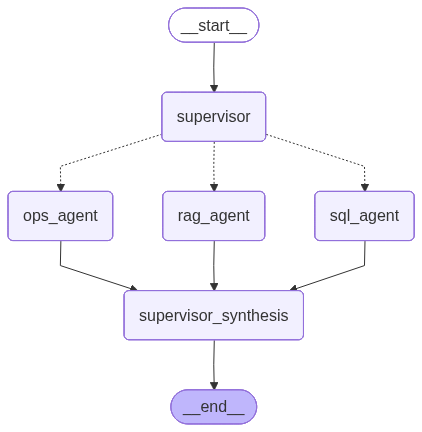

In [9]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("supervisor", supervisor_node)
    graph_builder.add_node("sql_agent", sql_agent_node)
    graph_builder.add_node("rag_agent", rag_agent_node)
    graph_builder.add_node("ops_agent", ops_agent_node)
    graph_builder.add_node("supervisor_synthesis", supervisor_synthesis_node)

    graph_builder.add_edge(START, "supervisor")

    graph_builder.add_conditional_edges(
        "supervisor",
        delegate_to_selected_agents,
        ["sql_agent", "rag_agent", "ops_agent"],
    )

    graph_builder.add_edge("sql_agent", "supervisor_synthesis")
    graph_builder.add_edge("rag_agent", "supervisor_synthesis")
    graph_builder.add_edge("ops_agent", "supervisor_synthesis")
    graph_builder.add_edge("supervisor_synthesis", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 10. Visualize Mermaid graph


In [10]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	sql_agent(sql_agent)
	rag_agent(rag_agent)
	ops_agent(ops_agent)
	supervisor_synthesis(supervisor_synthesis)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	ops_agent --> supervisor_synthesis;
	rag_agent --> supervisor_synthesis;
	sql_agent --> supervisor_synthesis;
	supervisor -.-> ops_agent;
	supervisor -.-> rag_agent;
	supervisor -.-> sql_agent;
	supervisor_synthesis --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 11. Visualize PNG graph


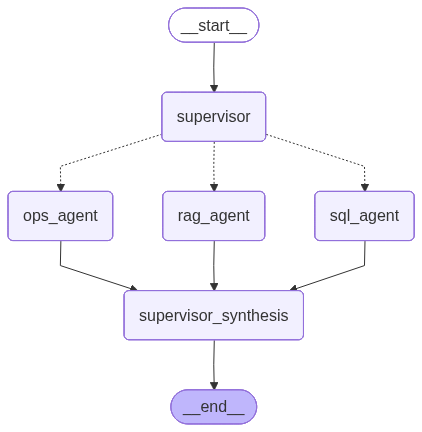

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 12. Test all-agent request


In [12]:
result = graph.invoke({
    "input": "Investigate CHECK-DOMAIN timeout spike after release R13 using metrics, docs, and operations checks."
})

print("Selected agents:", result["selected_agents"])
print()
print(result["final_answer"])


Selected agents: ['sql_agent', 'rag_agent', 'ops_agent']

**Conclusion:** The spike in CHECK-DOMAIN timeouts after release R13 is likely due to changes in the connection pool that have increased latency under saturation conditions.

**Supporting Evidence:**
- The SQL Agent identified a rise in CHECK-DOMAIN timeout volume post-release, with CONNECTION_TIMEOUT being the primary failure reason.
- The RAG Agent noted that R13 introduced connection pool changes, which could lead to increased latency when the system is under load.
- The Ops Agent suggested checking the health of the registry endpoint, DNS resolver latency, upstream connectivity, and connection pool saturation to diagnose the issue further.

**Recommended Next Action:** Conduct a thorough investigation of the connection pool configuration and performance metrics, along with the recommended checks on registry endpoint health and DNS resolver latency, to identify and mitigate the root cause of the timeout spikes.


## 13. Test docs-only request


In [13]:
result = graph.invoke({
    "input": "Use runbook and release notes to explain R13 CHECK-DOMAIN risk."
})

print("Selected agents:", result["selected_agents"])
print()
print(result["final_answer"])


Selected agents: ['rag_agent']

The R13 CHECK-DOMAIN risk is likely to lead to increased latency under saturation conditions due to the connection pool changes introduced in this release. Supporting evidence indicates that these changes can affect the performance of domain checks, particularly when system demand is high. As a recommended next action, it is advisable to monitor the system's performance closely and consider implementing load balancing or scaling strategies to mitigate potential latency issues.


## 14. Test metrics-only request


In [14]:
result = graph.invoke({
    "input": "Use metrics to summarize failure volume and latency after release R13."
})

print("Selected agents:", result["selected_agents"])
print()
print(result["final_answer"])


Selected agents: ['sql_agent']

After the release of R13, there has been an increase in failure volume, particularly related to CHECK-DOMAIN timeouts, with CONNECTION_TIMEOUT identified as the primary cause. To address this issue, it is recommended to investigate the underlying causes of the CONNECTION_TIMEOUT failures and implement optimizations to reduce latency and improve system reliability.


## 15. Why this matters

This is the enterprise pattern:

```text
Supervisor
  ├── SQL Agent
  ├── RAG Agent
  ├── Ops Agent
  └── Synthesis
```

Later versions can replace placeholder specialists with full subgraphs or remote agents.


## 16. LangSmith trace

Open project:

```text
langgraph-playground
```

Verify that only selected agents execute.
